In [1]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))

In [2]:
from src.transforms import trainval_transforms
from src.dataset import ImageDataset
import torch

annot_path = Path("../data/preprocessed/trainval/annotations.csv")
img_dir = Path("../data/preprocessed/trainval/images")

# test dataset without transforms
dataset = ImageDataset(annot_path, img_dir)

In [3]:
image, labels = next(iter(dataset))
image

tensor([[[0.0039, 0.0039, 0.0039,  ..., 0.6549, 0.6549, 0.6549],
         [0.1176, 0.0980, 0.0627,  ..., 0.6510, 0.6431, 0.6392],
         [0.4235, 0.4078, 0.3647,  ..., 0.6667, 0.6627, 0.6588],
         ...,
         [0.1020, 0.1255, 0.1765,  ..., 0.2588, 0.2588, 0.2314],
         [0.1294, 0.1686, 0.2392,  ..., 0.2314, 0.2471, 0.2392],
         [0.1647, 0.2314, 0.3098,  ..., 0.2118, 0.2471, 0.2549]],

        [[0.0431, 0.0431, 0.0431,  ..., 0.7294, 0.7294, 0.7294],
         [0.1569, 0.1373, 0.1020,  ..., 0.7294, 0.7216, 0.7176],
         [0.4667, 0.4510, 0.4078,  ..., 0.7529, 0.7490, 0.7451],
         ...,
         [0.0275, 0.0157, 0.0000,  ..., 0.3176, 0.3098, 0.2745],
         [0.0353, 0.0471, 0.0471,  ..., 0.2902, 0.2980, 0.2824],
         [0.0627, 0.0980, 0.1098,  ..., 0.2706, 0.2980, 0.2980]],

        [[0.0471, 0.0471, 0.0471,  ..., 0.7529, 0.7529, 0.7529],
         [0.1608, 0.1412, 0.1059,  ..., 0.7569, 0.7490, 0.7451],
         [0.4745, 0.4588, 0.4157,  ..., 0.7961, 0.7922, 0.

In [4]:
from src.transforms import revert_normalization

# unnormalize pixels
image = revert_normalization(image)

In [5]:
image

tensor([[[  1,   1,   1,  ..., 167, 167, 167],
         [ 30,  25,  16,  ..., 166, 164, 163],
         [108, 104,  93,  ..., 170, 169, 168],
         ...,
         [ 26,  32,  45,  ...,  66,  66,  59],
         [ 33,  43,  61,  ...,  59,  63,  61],
         [ 42,  59,  79,  ...,  54,  63,  65]],

        [[ 11,  11,  11,  ..., 186, 186, 186],
         [ 40,  35,  26,  ..., 186, 184, 183],
         [119, 115, 104,  ..., 192, 191, 190],
         ...,
         [  7,   4,   0,  ...,  81,  79,  70],
         [  9,  12,  12,  ...,  74,  76,  72],
         [ 16,  25,  28,  ...,  69,  76,  76]],

        [[ 12,  12,  12,  ..., 192, 192, 192],
         [ 41,  36,  27,  ..., 193, 191, 190],
         [121, 117, 106,  ..., 203, 202, 201],
         ...,
         [  3,   1,   2,  ..., 114, 111, 102],
         [  7,  10,  16,  ..., 107, 108, 104],
         [ 15,  24,  33,  ..., 102, 108, 108]]], dtype=torch.uint8)

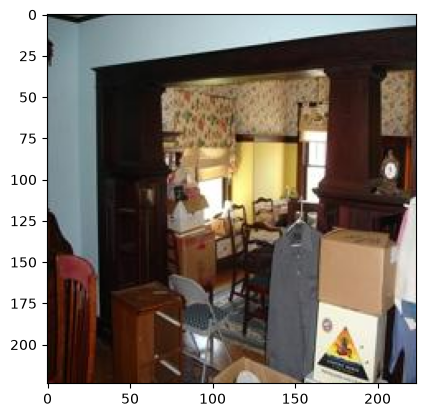

In [6]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots()

ax.imshow(image.permute(1, 2, 0))

plt.show()

In [7]:
image.shape, labels.shape

(torch.Size([3, 224, 224]), torch.Size([7, 7, 30]))

In [8]:
from src.transforms import revert_standardization

# test dataset with transforms
dataset = ImageDataset(annot_path, img_dir, transform=trainval_transforms)
iterable_dataset = iter(dataset)

In [9]:
image, labels = next(iterable_dataset)

In [10]:
image

tensor([[[-1.6468, -1.6468, -1.6468,  ...,  1.8184,  1.8184,  1.8184],
         [-1.1158, -1.2220, -1.4132,  ...,  1.8024,  1.7704,  1.7544],
         [ 0.5469,  0.4619,  0.2283,  ...,  1.8665,  1.8505,  1.8345],
         ...,
         [-1.3540, -1.2610, -1.0529,  ..., -0.2978, -0.3091, -0.4683],
         [-1.2326, -1.0569, -0.7637,  ..., -0.4465, -0.3729, -0.4258],
         [-1.0511, -0.7319, -0.3910,  ..., -0.5527, -0.3729, -0.3409]],

        [[-1.5094, -1.5094, -1.5094,  ...,  2.1325,  2.1325,  2.1325],
         [-0.8992, -1.0064, -1.1995,  ...,  2.1302,  2.1257,  2.1235],
         [ 0.7944,  0.7086,  0.4726,  ...,  2.1393,  2.1370,  2.1347],
         ...,
         [-1.5432, -1.5425, -1.5132,  ..., -0.0033, -0.0425, -0.2311],
         [-1.4902, -1.4100, -1.3643,  ..., -0.1534, -0.1069, -0.1882],
         [-1.3346, -1.1235, -1.0157,  ..., -0.2607, -0.1069, -0.1024]],

        [[-1.3097, -1.3097, -1.3097,  ...,  2.1527,  2.1527,  2.1527],
         [-0.7273, -0.8297, -1.0139,  ...,  2

In [11]:
revert_standardization(image)
image

tensor([[[0.0068, 0.0068, 0.0068,  ..., 0.9362, 0.9362, 0.9362],
         [0.1492, 0.1208, 0.0695,  ..., 0.9319, 0.9233, 0.9190],
         [0.5952, 0.5724, 0.5097,  ..., 0.9491, 0.9448, 0.9405],
         ...,
         [0.0854, 0.1103, 0.1661,  ..., 0.3686, 0.3656, 0.3229],
         [0.1179, 0.1651, 0.2437,  ..., 0.3287, 0.3485, 0.3343],
         [0.1666, 0.2522, 0.3436,  ..., 0.3003, 0.3485, 0.3571]],

        [[0.0242, 0.0242, 0.0242,  ..., 0.9911, 0.9911, 0.9911],
         [0.1862, 0.1577, 0.1064,  ..., 0.9905, 0.9893, 0.9887],
         [0.6358, 0.6130, 0.5504,  ..., 0.9929, 0.9923, 0.9917],
         ...,
         [0.0152, 0.0154, 0.0232,  ..., 0.4240, 0.4136, 0.3635],
         [0.0293, 0.0505, 0.0627,  ..., 0.3842, 0.3965, 0.3749],
         [0.0706, 0.1266, 0.1552,  ..., 0.3557, 0.3965, 0.3977]],

        [[0.0279, 0.0279, 0.0279,  ..., 0.9911, 0.9911, 0.9911],
         [0.1899, 0.1614, 0.1101,  ..., 0.9905, 0.9893, 0.9887],
         [0.6432, 0.6204, 0.5578,  ..., 0.9929, 0.9923, 0.

In [12]:
image = revert_normalization(image)
image

tensor([[[  1,   1,   1,  ..., 238, 238, 238],
         [ 38,  30,  17,  ..., 237, 235, 234],
         [151, 145, 129,  ..., 242, 240, 239],
         ...,
         [ 21,  28,  42,  ...,  93,  93,  82],
         [ 30,  42,  62,  ...,  83,  88,  85],
         [ 42,  64,  87,  ...,  76,  88,  91]],

        [[  6,   6,   6,  ..., 252, 252, 252],
         [ 47,  40,  27,  ..., 252, 252, 252],
         [162, 156, 140,  ..., 253, 253, 252],
         ...,
         [  3,   3,   5,  ..., 108, 105,  92],
         [  7,  12,  15,  ...,  97, 101,  95],
         [ 17,  32,  39,  ...,  90, 101, 101]],

        [[  7,   7,   7,  ..., 252, 252, 252],
         [ 48,  41,  28,  ..., 252, 252, 252],
         [164, 158, 142,  ..., 253, 253, 252],
         ...,
         [  3,   3,   5,  ..., 139, 135, 122],
         [  5,  11,  19,  ..., 129, 131, 125],
         [ 17,  31,  44,  ..., 121, 131, 131]]], dtype=torch.uint8)

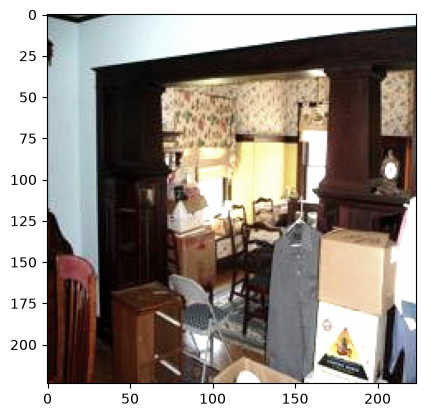

In [13]:
fig, ax = plt.subplots()

ax.imshow(image.permute(1, 2, 0))

plt.show()

In [14]:
# reversing standardization and normalization works